# 03 - MLP em PyTorch para Churn

Pipeline robusto de Rede Neural Multicamadas (MLP) em PyTorch para previsão de churn, com automação e rastreabilidade no MLflow.

**Sumário:**
1. Setup e bibliotecas
2. Preparação dos dados
3. Definição da arquitetura MLP (com BatchNorm e Dropout)
4. DataLoader e configuração de treinamento
5. Treinamento com mini-batches e early stopping
6. Avaliação completa (Accuracy, F1, ROC-AUC, PR-AUC, Confusion Matrix)
7. Comparação com baselines
8. Análise de trade-off de custo por threshold
9. Registro no MLflow

## 1) Setup e bibliotecas

Importação das principais bibliotecas utilizadas:
- PyTorch para modelagem e treinamento
- Numpy e pandas para manipulação de dados
- Matplotlib para visualização
- Configuração do device (GPU/CPU)

In [1]:
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from joblib import load

import mlflow
import mlflow.pytorch
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
)

# ── Seeds globais para reprodutibilidade ────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device em uso: {device}')

# Constantes de negócio (mesmas do notebook de baselines)
V_RETIDO = 500.0   # valor retido por churn evitado (R$)
C_ACAO   = 50.0    # custo de abordagem por cliente (R$)

Device em uso: cpu


## 2) Preparação dos dados
Reaproveitamento do pipeline de preprocessamento do baseline para garantir comparabilidade entre modelos.

- Carrega os splits já tratados (X_train, X_test, y_train, y_test) exportados do notebook baseline.
- Converte todos os dados para arrays float32, garantindo compatibilidade com PyTorch.
- Exporta os dados como tensores PyTorch prontos para uso no modelo.

In [2]:
import os

# Resolve o caminho independente de onde o notebook e executado (VS Code, Jupyter, make)
_cwd = Path(os.path.abspath(''))
if _cwd.name == 'notebooks':
    splits_path = _cwd.parent / 'data/processed/baseline_splits_arrays.joblib'
else:
    splits_path = _cwd / 'data/processed/baseline_splits_arrays.joblib'

if not splits_path.exists():
    raise FileNotFoundError(
        'Arquivo nao encontrado: ' + str(splits_path) +
        ' - Execute o notebook 02_baselines.ipynb primeiro.'
    )

X_train, X_test, y_train, y_test = load(splits_path)

print(f'X_train: {X_train.shape} | dtype: {X_train.dtype}')
print(f'X_test : {X_test.shape}  | dtype: {X_test.dtype}')
print(f'y_train: {y_train.shape} | churn rate: {y_train.mean():.3f}')
print(f'y_test : {y_test.shape}  | churn rate: {y_test.mean():.3f}')

X_train: (39239, 101) | dtype: float32
X_test : (9810, 101)  | dtype: float32
y_train: (39239,) | churn rate: 0.394
y_test : (9810,)  | churn rate: 0.394


In [3]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).to(device)

print(f"Tensores criados — X_train: {X_train_tensor.shape} | X_test: {X_test_tensor.shape}")

Tensores criados — X_train: torch.Size([39239, 101]) | X_test: torch.Size([9810, 101])


## 3) Definição da arquitetura MLP

MLP com duas camadas ocultas, BatchNorm e Dropout para regularização.

- **BatchNorm1d**: estabiliza o treinamento e acelera a convergência
- **Dropout**: reduz overfitting ao desativar neurônios aleatoriamente durante o treino
- **Saída sem ativação**: usamos `BCEWithLogitsLoss`, que combina Sigmoid + BCE de forma numericamente estável

In [4]:
# Importa a classe MLP do pacote src/churn_prediction/model.py
#
# CRÍTICO: usar a classe importada (em vez de definir localmente) garante que
# o módulo da classe seja `churn_prediction.model` e não `__main__`. Sem isso,
# o modelo PyTorch logado no MLflow tem referência a `__main__.MLP`, o que
# quebra a desserialização em outros processos (ex: scripts/export_model.py).
#
# Veja: docs/decisions/003-arquitetura-mlp-128-64.md
from churn_prediction.model import MLP

input_dim = X_train_tensor.shape[1]
model = MLP(input_dim).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {total_params:,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=101, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parâmetros treináveis: 21,761


## 4) DataLoader e configuração de treinamento

Configura mini-batches e reserva 10% do treino como validação interna para early stopping.

- **Batching**: divide o treino em lotes, reduzindo uso de memória e permitindo atualizações mais frequentes
- **Early stopping**: interrompe o treino quando a val_loss para de melhorar (evita overfitting)
- **ReduceLROnPlateau**: reduz o LR automaticamente se a val_loss estagna

In [5]:
# Hiperparâmetros de treinamento
BATCH_SIZE = 512
LR         = 1e-3
N_EPOCHS   = 100
PATIENCE   = 10    # early stopping: epochs sem melhora na val_loss
HIDDEN1    = 128
HIDDEN2    = 64
DROPOUT    = 0.3

# DataLoaders
full_train_ds = TensorDataset(X_train_tensor, y_train_tensor)
val_size      = int(0.1 * len(full_train_ds))
train_size    = len(full_train_ds) - val_size
train_ds, val_ds = random_split(
    full_train_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Treino: {train_size:,} amostras | Validação: {val_size:,} | Teste: {len(y_test_tensor):,}")
print(f"Batches por epoch: {len(train_loader)}")

Treino: 35,316 amostras | Validação: 3,923 | Teste: 9,810
Batches por epoch: 69


## 5) Treinamento com mini-batches e early stopping

Epoch   1/100 | train_loss: 0.5021 | val_loss: 0.4470


Epoch  10/100 | train_loss: 0.4080 | val_loss: 0.4293


Epoch  20/100 | train_loss: 0.3901 | val_loss: 0.4333



Early stopping na epoch 21 — melhor val_loss: 0.4284

Modelo restaurado ao estado da melhor epoch (val_loss: 0.4284)


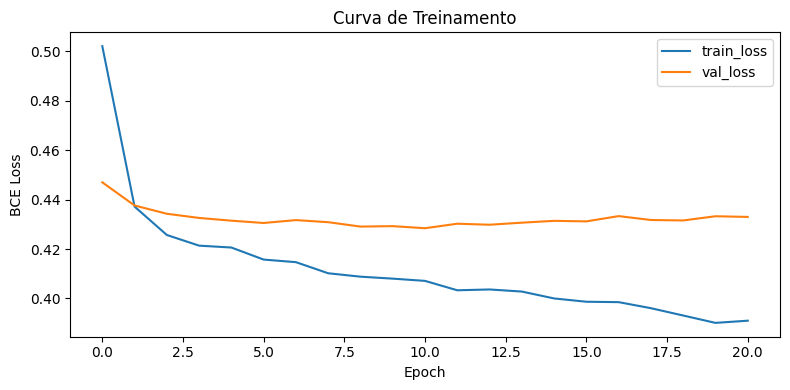

In [6]:
model     = MLP(input_dim, hidden1=HIDDEN1, hidden2=HIDDEN2, dropout=DROPOUT).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

best_val_loss    = float('inf')
best_state       = None
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    # --- treino ---
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch).squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = float(np.mean(batch_losses))

    # --- validação ---
    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            loss = criterion(model(X_batch).squeeze(), y_batch)
            val_batch_losses.append(loss.item())
    val_loss = float(np.mean(val_batch_losses))

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # --- early stopping ---
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_state       = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping na epoch {epoch+1} — melhor val_loss: {best_val_loss:.4f}")
        break

model.load_state_dict(best_state)
print(f"\nModelo restaurado ao estado da melhor epoch (val_loss: {best_val_loss:.4f})")

# Curva de loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='train_loss')
ax.plot(val_losses,   label='val_loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Curva de Treinamento')
ax.legend()
plt.tight_layout()
plt.show()

## 6) Avaliação completa no conjunto de teste

Métricas avaliadas: Accuracy, F1, ROC-AUC, PR-AUC, Confusion Matrix.

Accuracy : 0.8064
F1       : 0.7425
ROC-AUC  : 0.8772
PR-AUC   : 0.8464
Valor Líquido: R$ 1,193,350 (TP=2738, FP=775)

              precision    recall  f1-score   support

   Nao Churn       0.82      0.87      0.84      5948
       Churn       0.78      0.71      0.74      3862

    accuracy                           0.81      9810
   macro avg       0.80      0.79      0.79      9810
weighted avg       0.80      0.81      0.80      9810



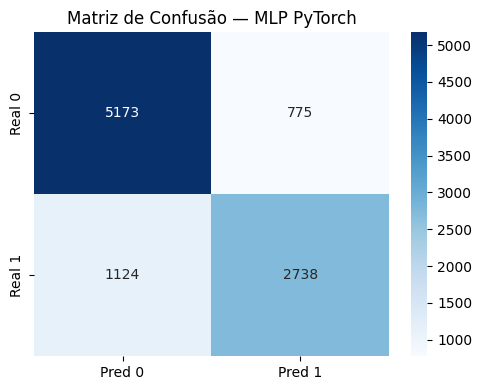

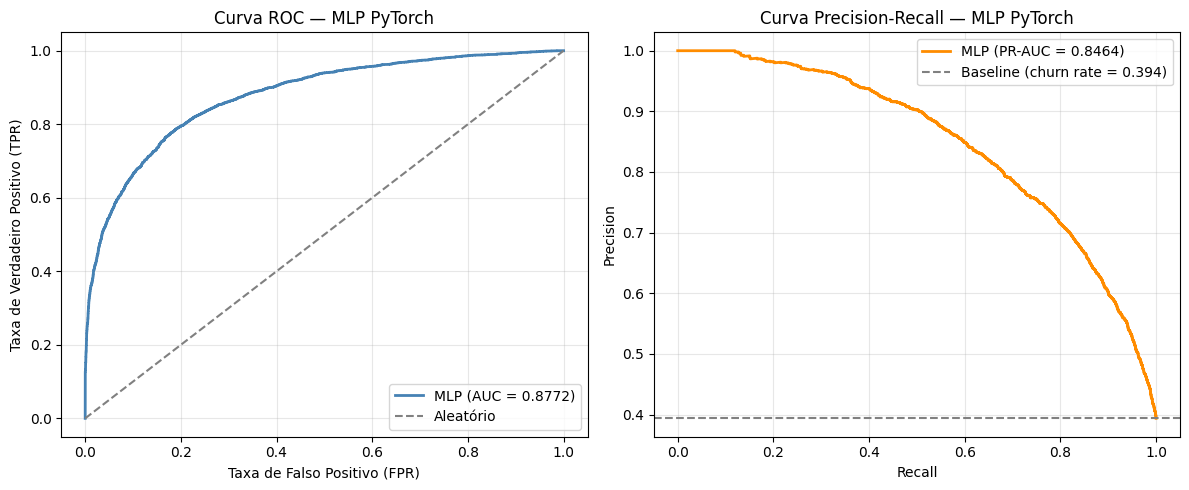

In [7]:
model.eval()
with torch.no_grad():
    logits_test = model(X_test_tensor).squeeze()
    probs_test  = torch.sigmoid(logits_test).cpu().numpy()
    preds_test  = (probs_test >= 0.5).astype(int)
    y_true      = y_test_tensor.cpu().numpy().astype(int)

acc     = accuracy_score(y_true, preds_test)
f1      = f1_score(y_true, preds_test)
roc_auc = roc_auc_score(y_true, probs_test)
pr_auc  = average_precision_score(y_true, probs_test)
cm      = confusion_matrix(y_true, preds_test)

tp = int(((y_true == 1) & (preds_test == 1)).sum())
fp = int(((y_true == 0) & (preds_test == 1)).sum())
valor_liquido = tp * V_RETIDO - (tp + fp) * C_ACAO

print(f"Accuracy : {acc:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print(f"Valor Líquido: R$ {valor_liquido:,.0f} (TP={tp}, FP={fp})")
print(f"\n{classification_report(y_true, preds_test, target_names=['Nao Churn', 'Churn'])}")

# Matriz de confusão
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Real 0', 'Real 1'], ax=ax)
ax.set_title('Matriz de Confusão — MLP PyTorch')
plt.tight_layout()
plt.show()
# Curva ROC
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_true, probs_test)
precision, recall, _ = precision_recall_curve(y_true, probs_test)
baseline_precision = y_true.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label='MLP (AUC = ' + '{:.4f}'.format(roc_auc) + ')')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório')
axes[0].set_xlabel('Taxa de Falso Positivo (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
axes[0].set_title('Curva ROC — MLP PyTorch')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall
axes[1].plot(recall, precision, color='darkorange', lw=2, label='MLP (PR-AUC = ' + '{:.4f}'.format(pr_auc) + ')')
axes[1].axhline(y=baseline_precision, color='gray', linestyle='--', label='Baseline (churn rate = ' + '{:.3f}'.format(baseline_precision) + ')')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — MLP PyTorch')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7) Comparação com baselines

Compara o MLP com os resultados do `DummyClassifier` e `LogisticRegression` do notebook anterior.

In [8]:
# Resultados dos baselines — carregados do MLflow local para comparação dinâmica
import mlflow

mlflow.set_tracking_uri(str("file:" + str(_cwd.parent / "mlruns" if _cwd.name == "notebooks" else _cwd / "mlruns")))

def read_mlflow_run(experiment_name: str, run_name: str) -> dict:
    """Lê métricas de uma run pelo nome do experimento e da run."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(experiment_name)
    if exp is None:
        return {}
    runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.mlflow.runName = '{run_name}'",
        order_by=["start_time DESC"],
        max_results=1,
    )
    if not runs:
        return {}
    return {k: v for k, v in runs[0].data.metrics.items()}

baseline_names = [
    ("churn-baselines", "dummy_stratified"),
    ("churn-baselines", "log_reg"),
    ("churn-baselines", "random_forest"),
    ("churn-baselines", "gradient_boosting"),
]

comparison_rows = {}
for exp_name, run_name in baseline_names:
    m = read_mlflow_run(exp_name, run_name)
    if m:
        comparison_rows[run_name] = {
            "accuracy":      m.get("accuracy", float("nan")),
            "f1":            m.get("f1", float("nan")),
            "roc_auc":       m.get("roc_auc", float("nan")),
            "pr_auc":        m.get("pr_auc", float("nan")),
            "valor_liquido": m.get("valor_liquido", float("nan")),
        }

comparison_rows["mlp_pytorch"] = {
    "accuracy":      acc,
    "f1":            f1,
    "roc_auc":       roc_auc,
    "pr_auc":        pr_auc,
    "valor_liquido": valor_liquido,
}

comparison_df = pd.DataFrame(comparison_rows).T
comparison_df.index.name = "modelo"
comparison_df = comparison_df.sort_values("roc_auc", ascending=False)

print("=" * 75)
print("Comparação completa de modelos (lineares + árvores + MLP)")
print("=" * 75)
print(comparison_df.to_string(float_format="{:.4f}".format))

best_baseline = comparison_df.drop("mlp_pytorch").index[0]
delta_roc = roc_auc  - comparison_df.loc[best_baseline, "roc_auc"]
delta_f1  = f1       - comparison_df.loc[best_baseline, "f1"]
delta_vl  = valor_liquido - comparison_df.loc[best_baseline, "valor_liquido"]
print(f"\nGanho MLP vs. melhor baseline ({best_baseline}):")
print(f"  ROC-AUC : {delta_roc:+.4f}")
print(f"  F1      : {delta_f1:+.4f}")
print(f"  Valor   : R$ {delta_vl:+,.0f}")

Comparação completa de modelos (lineares + árvores + MLP)
                   accuracy     f1  roc_auc  pr_auc  valor_liquido
modelo                                                            
gradient_boosting    0.8137 0.7474   0.8815  0.8541   1183300.0000
log_reg              0.8069 0.7425   0.8783  0.8480   1190800.0000
mlp_pytorch          0.8064 0.7425   0.8772  0.8464   1193350.0000
random_forest        0.7950 0.7154   0.8609  0.8225   1103750.0000
dummy_stratified     0.5294 0.3937   0.5046  0.3959    561850.0000

Ganho MLP vs. melhor baseline (gradient_boosting):
  ROC-AUC : -0.0043
  F1      : -0.0049
  Valor   : R$ +10,050


## 7a) Feature Importance — Random Forest e Gradient Boosting

Identifica quais variáveis mais influenciam a previsão de churn nos modelos de ensemble (critério Aula 04).

- Reconstrói o preprocessador do notebook de baselines para obter os nomes reais das features
- Treina RF e GB rápidos (50 árvores) sobre os dados já preprocessados
- Compara as top-20 features entre os dois modelos

Feature names obtidas: 101 (match com X_train OK)
Treinando Random Forest (50 arvores)...


Treinando Gradient Boosting (50 arvores)...


Pronto!


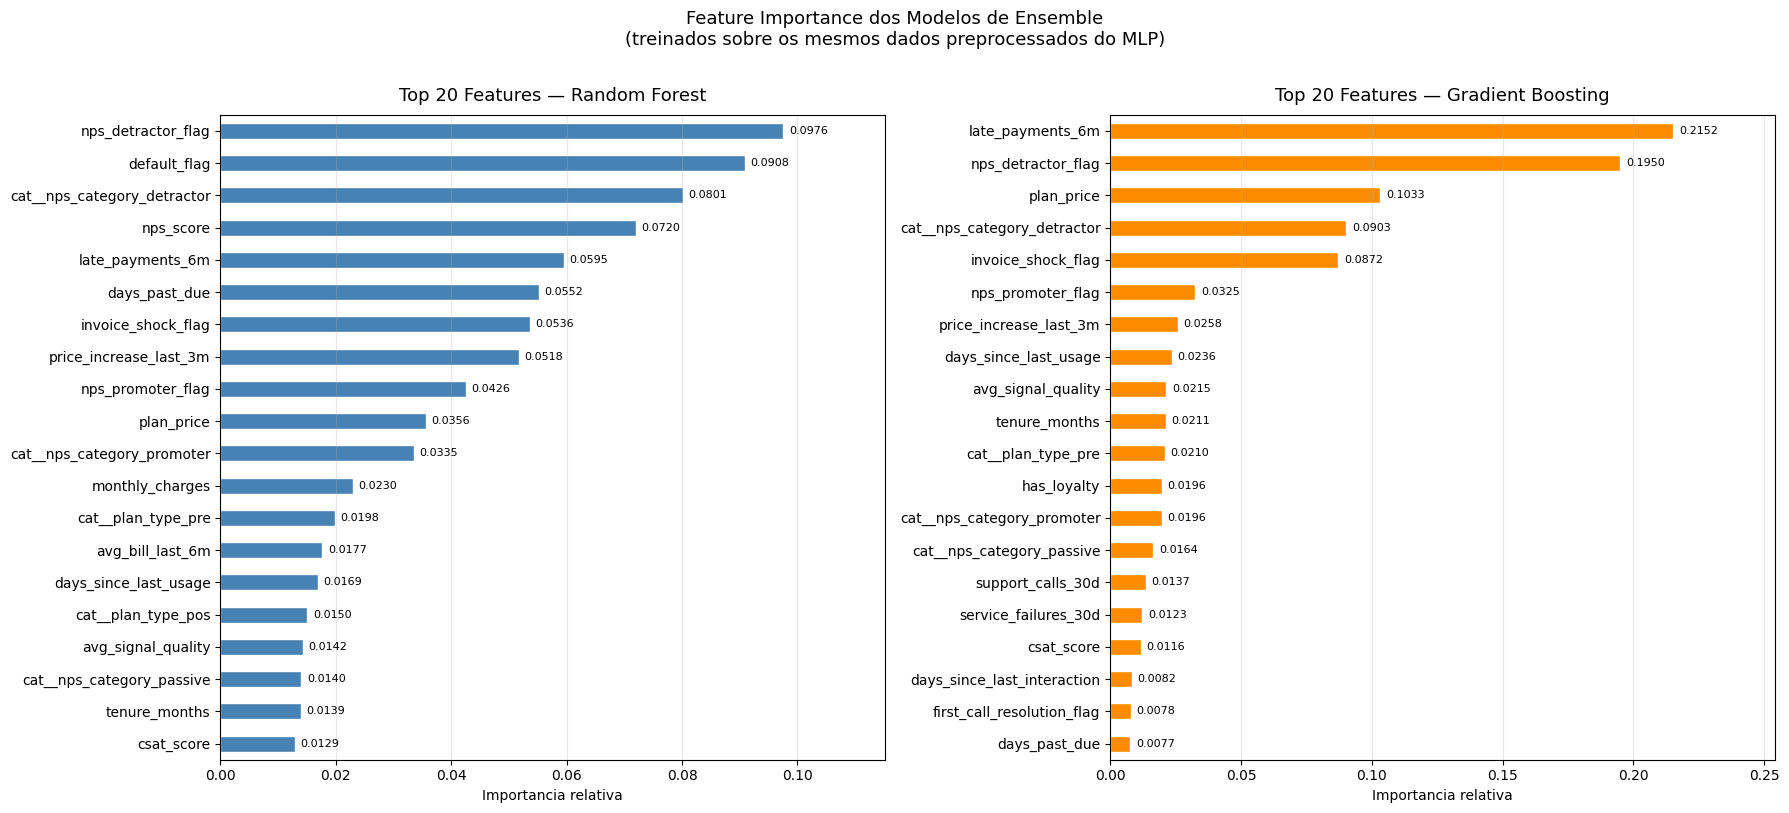


Features no Top-10 de AMBOS os modelos (7):
Feature                                             RF       GB
-----------------------------------------------------------------
nps_detractor_flag                              0.0976   0.1950
cat__nps_category_detractor                     0.0801   0.0903
late_payments_6m                                0.0595   0.2152
invoice_shock_flag                              0.0536   0.0872
price_increase_last_3m                          0.0518   0.0258
nps_promoter_flag                               0.0426   0.0325
plan_price                                      0.0356   0.1033


In [9]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Carrega raw data e aplica mesma limpeza do notebook de baselines
_raw_path = (
    _cwd.parent / 'data/raw/telecom_churn_base_extended.csv'
    if _cwd.name == 'notebooks'
    else _cwd / 'data/raw/telecom_churn_base_extended.csv'
)
df_raw = pd.read_csv(_raw_path)
df_raw = df_raw.drop_duplicates().copy()
if 'customer_id' in df_raw.columns:
    df_raw = df_raw.drop_duplicates(subset=['customer_id'], keep='first')
if 'gender' in df_raw.columns:
    df_raw['gender'] = (
        df_raw['gender'].astype(str).str.strip().str.lower()
        .replace({'': np.nan, 'nan': np.nan}).fillna('unknown')
    )
if 'plan_type' in df_raw.columns:
    df_raw['plan_type'] = (
        df_raw['plan_type'].astype(str).str.strip().str.lower()
        .replace({'desconhecido': 'unknown', '??': 'unknown', 'nan': 'unknown'})
    )
if 'payment_method' in df_raw.columns:
    valid_pm = {'boleto', 'debito', 'card', 'pix'}
    df_raw['payment_method'] = df_raw['payment_method'].apply(
        lambda x: x if str(x).strip().lower() in valid_pm else 'unknown'
    )
if 'age' in df_raw.columns:
    df_raw['age_group'] = pd.cut(
        df_raw['age'],
        bins=[0, 24, 34, 44, 54, 120],
        labels=['<25', '25-34', '35-44', '45-54', '55+'],
        include_lowest=True,
    ).astype(str).replace({'nan': 'unknown'})
    df_raw['age'] = df_raw['age'].clip(18, 100)

LEAKAGE_COLS = [
    'customer_id', 'churn_probability',
    'retention_offer_made', 'retention_offer_accepted',
    'contract_renewal_date', 'loyalty_end_date',
]
df_raw = df_raw.drop(columns=[c for c in LEAKAGE_COLS if c in df_raw.columns])

X_raw = df_raw.drop(columns=['churn'])
num_cols_raw = X_raw.select_dtypes(include=['number']).columns.tolist()
cat_cols_raw = [c for c in X_raw.columns if c not in num_cols_raw]

# 2. Reconstroi o preprocessador apenas para obter os nomes das features
preproc_names = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imp',    SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols_raw),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cat_cols_raw),
    ]
)
preproc_names.fit(X_raw)
raw_names = preproc_names.get_feature_names_out()
feature_names = [
    n.replace('num__', '').replace('cat__ohe__', '')
    for n in raw_names
]
n_feat  = len(feature_names)
n_train = X_train.shape[1]
if n_feat != n_train:
    print('Aviso: preprocessador gerou ' + str(n_feat) + ' features, X_train tem ' + str(n_train) + '. Usando indices.')
    feature_names = ['feature_' + str(i) for i in range(n_train)]
else:
    print('Feature names obtidas: ' + str(n_feat) + ' (match com X_train OK)')

# 3. Treina RF e GB rapidos sobre os dados ja preprocessados
print('Treinando Random Forest (50 arvores)...')
rf_fi = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_fi.fit(X_train, y_train)

print('Treinando Gradient Boosting (50 arvores)...')
gb_fi = GradientBoostingClassifier(n_estimators=50, max_depth=4, learning_rate=0.1, random_state=42)
gb_fi.fit(X_train, y_train)
print('Pronto!')

# 4. Top-20 features de cada modelo
TOP_N = 20
rf_imp = pd.Series(rf_fi.feature_importances_, index=feature_names).sort_values(ascending=False).head(TOP_N)
gb_imp = pd.Series(gb_fi.feature_importances_, index=feature_names).sort_values(ascending=False).head(TOP_N)

# 5. Grafico lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, imp, title, color in [
    (axes[0], rf_imp, 'Random Forest',     'steelblue'),
    (axes[1], gb_imp, 'Gradient Boosting', 'darkorange'),
]:
    imp_sorted = imp.sort_values()
    imp_sorted.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title('Top ' + str(TOP_N) + ' Features \u2014 ' + title, fontsize=13, pad=10)
    ax.set_xlabel('Importancia relativa')
    ax.set_xlim(0, imp_sorted.max() * 1.18)
    for bar, val in zip(ax.patches, imp_sorted.values):
        ax.text(
            val + imp_sorted.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            '{:.4f}'.format(val), va='center', fontsize=8,
        )
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(
    'Feature Importance dos Modelos de Ensemble\n'
    '(treinados sobre os mesmos dados preprocessados do MLP)',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

# 6. Features em comum no top-10 dos dois modelos
common_top10 = set(rf_imp.index[:10]) & set(gb_imp.index[:10])
print('\nFeatures no Top-10 de AMBOS os modelos (' + str(len(common_top10)) + '):')
print('{:<45} {:>8} {:>8}'.format('Feature', 'RF', 'GB'))
print('-' * 65)
for feat in sorted(common_top10, key=lambda fv: -rf_imp.get(fv, 0)):
    print('{:<45} {:>8.4f} {:>8.4f}'.format(feat, rf_imp.get(feat, 0), gb_imp.get(feat, 0)))


## 8) Análise de trade-off de custo por threshold

Varre thresholds de 0.10 a 0.90 para identificar o ponto de máximo valor líquido da campanha de retenção.

- **FP** (falso positivo) = cliente abordado desnecessariamente → custo `C_ACAO`
- **FN** (falso negativo) = churn não capturado → perda de `V_RETIDO`
- **Valor líquido** = TP × V_RETIDO − (TP + FP) × C_ACAO

 threshold   tp   fp   fn  clientes_abordados     f1  valor_liquido
      0.10 3707 3642  155                7349 0.6613      1486050.0
      0.15 3585 2767  277                6352 0.7020      1474900.0
      0.20 3445 2192  417                5637 0.7253      1440650.0
      0.25 3338 1830  524                5168 0.7393      1410600.0
      0.30 3234 1515  628                4749 0.7511      1379550.0
      0.35 3108 1262  754                4370 0.7551      1335500.0
      0.40 2989 1058  873                4047 0.7558      1292150.0
      0.45 2853  915 1009                3768 0.7478      1238100.0
      0.50 2738  775 1124                3513 0.7425      1193350.0
      0.55 2611  640 1251                3251 0.7341      1142950.0
      0.60 2487  531 1375                3018 0.7230      1092600.0
      0.65 2343  434 1519                2777 0.7058      1032650.0
      0.70 2182  331 1680                2513 0.6845       965350.0
      0.75 2011  244 1851                2255 0.

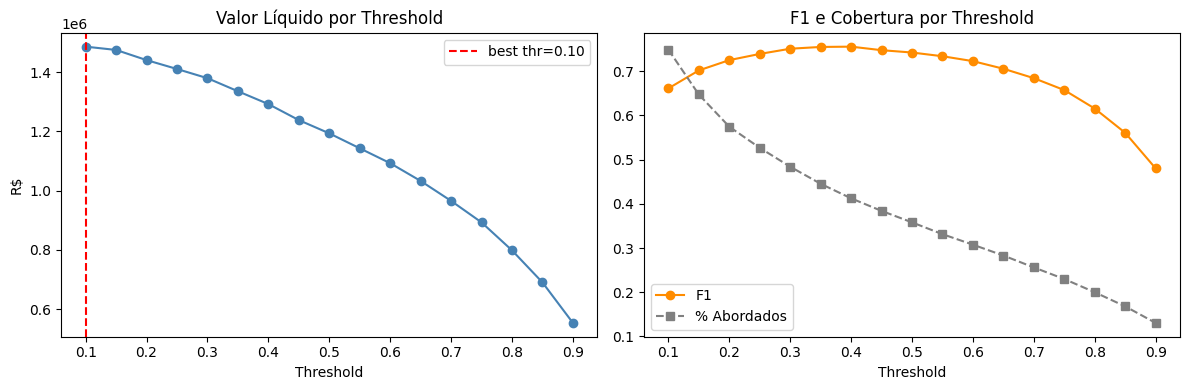

In [10]:
thresholds = np.arange(0.10, 0.91, 0.05)
thr_results = []

for thr in thresholds:
    p = (probs_test >= thr).astype(int)
    tp_t  = int(((y_true == 1) & (p == 1)).sum())
    fp_t  = int(((y_true == 0) & (p == 1)).sum())
    fn_t  = int(((y_true == 1) & (p == 0)).sum())
    vl    = tp_t * V_RETIDO - (tp_t + fp_t) * C_ACAO
    f1_t  = f1_score(y_true, p, zero_division=0)
    thr_results.append({
        'threshold': round(thr, 2),
        'tp': tp_t, 'fp': fp_t, 'fn': fn_t,
        'clientes_abordados': tp_t + fp_t,
        'f1': round(f1_t, 4),
        'valor_liquido': round(vl, 0),
    })

thr_df   = pd.DataFrame(thr_results)
best_idx = thr_df['valor_liquido'].idxmax()
best_thr = thr_df.loc[best_idx, 'threshold']

print(thr_df.to_string(index=False))
print(f"\nMelhor threshold por valor líquido: {best_thr:.2f}")
print(f"  Valor líquido: R$ {thr_df.loc[best_idx, 'valor_liquido']:,.0f}")
print(f"  Clientes abordados: {int(thr_df.loc[best_idx, 'clientes_abordados']):,}")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thr_df['threshold'], thr_df['valor_liquido'], marker='o', color='steelblue')
axes[0].axvline(best_thr, color='red', linestyle='--', label=f'best thr={best_thr:.2f}')
axes[0].set_title('Valor Líquido por Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('R$')
axes[0].legend()

axes[1].plot(thr_df['threshold'], thr_df['f1'], marker='o', color='darkorange', label='F1')
axes[1].plot(thr_df['threshold'], thr_df['clientes_abordados'] / len(y_true),
             marker='s', linestyle='--', color='gray', label='% Abordados')
axes[1].set_title('F1 e Cobertura por Threshold')
axes[1].set_xlabel('Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9) Registro no MLflow

In [11]:
mlflow.set_tracking_uri(str("file:" + str(_cwd.parent / "mlruns" if _cwd.name == "notebooks" else _cwd / "mlruns")))
mlflow.set_experiment("churn-mlp-pytorch")

with mlflow.start_run(run_name="mlp_pytorch_v1"):
    # Parâmetros
    mlflow.log_params({
        "model":                  "mlp_pytorch",
        "architecture":           f"{input_dim}->{HIDDEN1}->{HIDDEN2}->1",
        "hidden1":                HIDDEN1,
        "hidden2":                HIDDEN2,
        "dropout":                DROPOUT,
        "batch_size":             BATCH_SIZE,
        "learning_rate":          LR,
        "optimizer":              "Adam",
        "weight_decay":           1e-4,
        "loss_fn":                "BCEWithLogitsLoss",
        "early_stopping_patience": PATIENCE,
        "best_threshold":         float(best_thr),
        "epochs_trained":         len(train_losses),
    })

    # Métricas técnicas
    mlflow.log_metrics({
        "accuracy":            float(acc),
        "f1":                  float(f1),
        "roc_auc":             float(roc_auc),
        "pr_auc":              float(pr_auc),
        "best_val_loss":       float(best_val_loss),
    })

    # Métricas de negócio
    mlflow.log_metrics({
        "tp":                  float(tp),
        "fp":                  float(fp),
        "clientes_abordados":  float(tp + fp),
        "valor_liquido":       float(valor_liquido),
        "valor_por_cliente":   float(valor_liquido / len(y_true)),
    })

    mlflow.pytorch.log_model(model, "mlp_model")

    run_id = mlflow.active_run().info.run_id
    print(f"Experimento registrado — run_id: {run_id}")
    print(f"Acesse: mlflow ui --backend-store-uri ./mlruns  (ou make mlflow-up)")

2026/04/24 21:04:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Experimento registrado — run_id: fbd3302d930c46e799b9240b2e7b7229
Acesse: mlflow ui --backend-store-uri ./mlruns  (ou make mlflow-up)
